In [1]:
import pandas as pd
import statsmodels.formula.api as smf

In [3]:
df = pd.read_excel("TOP 2500 final.xlsx")
df

,SKU,ASIN,TOTAL QUANTITY,Descrption,Auction Title,A & A+ Content,Classification,Rating,Review Count,Total Images,Total Videos
0,11461,B00FM6BPVU,1983,NOVICA Artisan Crafted Hand Blown Clear Cobalt...,"Blown glass drinking glasses, 'Classic' (set o...",Not A and A+ Content,Tableware & Entertaining,4.8 out of 5 stars,958 ratings,8,2
1,83019,B0002JLL6G,1331,NOVICA Large Blue Hand Blown Glass Pitcher For...,"Handblown glass pitcher, 'Pure Cobalt'",Not A and A+ Content,Tableware & Entertaining,4.7 out of 5 stars,"1,090 ratings",8,2
2,194533,B00FPFT9X4,810,NOVICA Artisan Handmade Citrine .925 Sterling ...,"Pearl and citrine cluster earrings, 'Radiant L...",A+,Jewelry,4.6 out of 5 stars,640 ratings,8,1
3,420620,B0BGT49LJN,508,NOVICA Artisan Handmade Wooden Dala Horses | W...,"Wood ornaments, 'Dala Tradition' (set of 4)",A+,Holiday Decor & Ornaments,4.4 out of 5 stars,34 ratings,8,2
4,300838,B0855K28SZ,415,NOVICA Artisan Handcrafted Garnet Dangle Earri...,"Garnet dangle earrings, 'Natural Moonlight'",A+,Jewelry,4.6 out of 5 stars,667 ratings,8,1
...,...,...,...,...,...,...,...,...,...,...,...
2495,316968a149621,B07YVN4XFV,2,NOVICA Artisan Handmade Gold Accented Sterling...,"Gold accented sterling silver band ring, 'Anci...",Not A and A+ Content,Jewelry,Previous set of slides,0,9,0
2496,382231a195615,B07KT3DLTW,2,NOVICA Artisan handmade sterling silver band r...,"Sterling silver band ring, 'Rice Stalks'",Not A and A+ Content,Jewelry,4.0 out of 5 stars,1 rating,8,1
2497,371940a188700,B07KR3VKTZ,2,NOVICA Artisan Handmade .925 Sterling Silver B...,"Sterling silver band ring, 'Bold Circles'",Not A and A+ Content,Jewelry,5.0 out of 5 stars,1 rating,8,1
2498,317516a150169,B07YVMJ4D1,2,NOVICA Artisan Handmade 100% Alpaca Cardigan B...,"100% alpaca cardigan, 'Sea Blooms'",Not A and A+ Content,Clothing & Accessories,5.0 out of 5 stars,1 rating,9,0


In [5]:
df = df.rename(columns={
    "TOTAL QUANTITY": "total_qty",
    "Total Images": "total_images",
    "Total Videos": "total_videos",
    "Rating": "rating",
    "A & A+ Content": "a_plus_content",
    "Classification": "classification"
})

In [7]:
# 3. (Optional) Drop rows with missing predictors/target
model_df = df[["total_qty",
               "total_images",
               "total_videos",
               "rating",
               "a_plus_content",
               "classification"]].dropna()

In [9]:
base_formula = """
total_qty ~ total_images + total_videos + rating
            + C(a_plus_content) + C(classification)
"""

base_model = smf.ols(formula=base_formula, data=model_df).fit(cov_type="HC3")
print("\n=== BASE MODEL ===")
print(base_model.summary())


=== BASE MODEL ===
                            OLS Regression Results                            
Dep. Variable:              total_qty   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     10.95
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.89e-97
Time:                        19:28:36   Log-Likelihood:                -13710.
No. Observations:                2500   AIC:                         2.756e+04
Df Residuals:                    2431   BIC:                         2.796e+04
Df Model:                          68                                         
Covariance Type:                  HC3                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

# The model explains a modest slice (≈8%) of sales variation, so content is important but not the full story.

# A+ content has a clear, statistically significant uplift (~+22 units) vs the baseline content type.

# More images and especially more videos are associated with higher unit sales; videos show the strongest marginal effect.

# Star rating, by itself, does not show a strong independent effect once category and content are controlled for.

# Product classification still matters: some categories structurally sell more/less even with similar content.

In [48]:
# --- Clean A/A+ Content column ---
def clean_aplus(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    # normalize text
    if s in ["a+", "a +", "a plus"]:
        return 2
    elif s in ["a", " a "]:
        return 1
    elif s in ["not a", "not a+", "not a, a+", "no a", "none", "na"]:
        return 0

    # fallback logic
    if "a+" in s:
        return 2
    if s == "a":
        return 1
    return 0

df_obj4["aplus_num"] = df_obj4["a_plus_content"].apply(clean_aplus)



In [79]:
# === Two-way ANOVA: sales ~ A+ × Category ===
model_anova_aplus = smf.ols('sales ~ C(aplus_num) * C(category)', data=df_obj4).fit()
anova_aplus = anova_lm(model_anova_aplus, typ=2)

print("=== TWO-WAY ANOVA: sales ~ A+ × Category ===")
print(anova_aplus)


=== TWO-WAY ANOVA: sales ~ A+ × Category ===
                                sum_sq      df          F    PR(>F)
C(aplus_num)              2.484676e+00     1.0   0.000927  0.975713
C(category)               1.327232e+05    25.0   1.980658  0.002575
C(aplus_num):C(category)  6.705741e+05    25.0  10.007131  0.000046
Residual                  9.338461e+06  3484.0        NaN       NaN


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 2
  warnings.warn('covariance of constraints does not have full '


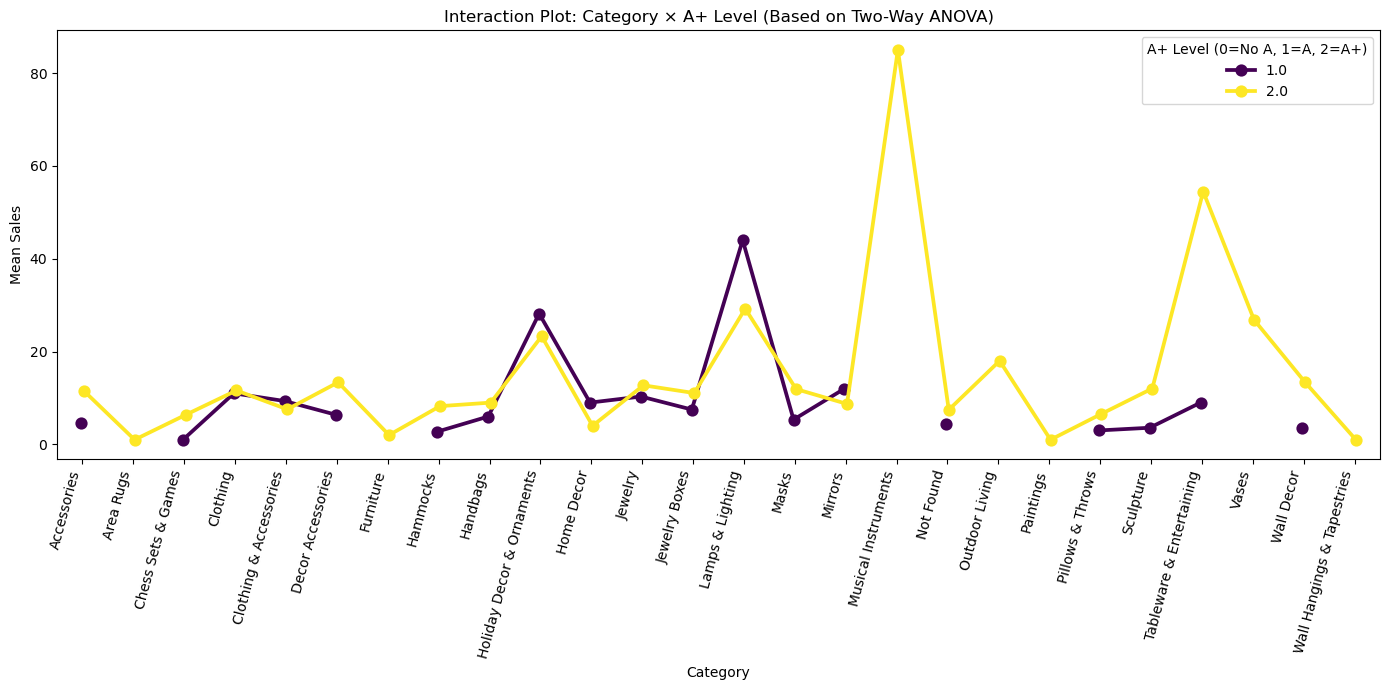

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare mean table
mean_table = (
    df_obj4
    .groupby(["category", "aplus_num"])["sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))
sns.pointplot(
    data=mean_table,
    x="category",
    y="sales",
    hue="aplus_num",
    palette="viridis",
    dodge=True
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Category")
plt.ylabel("Mean Sales")
plt.title("Interaction Plot: Category × A+ Level (Based on Two-Way ANOVA)")
plt.legend(title="A+ Level (0=No A, 1=A, 2=A+)")
plt.tight_layout()
plt.show()


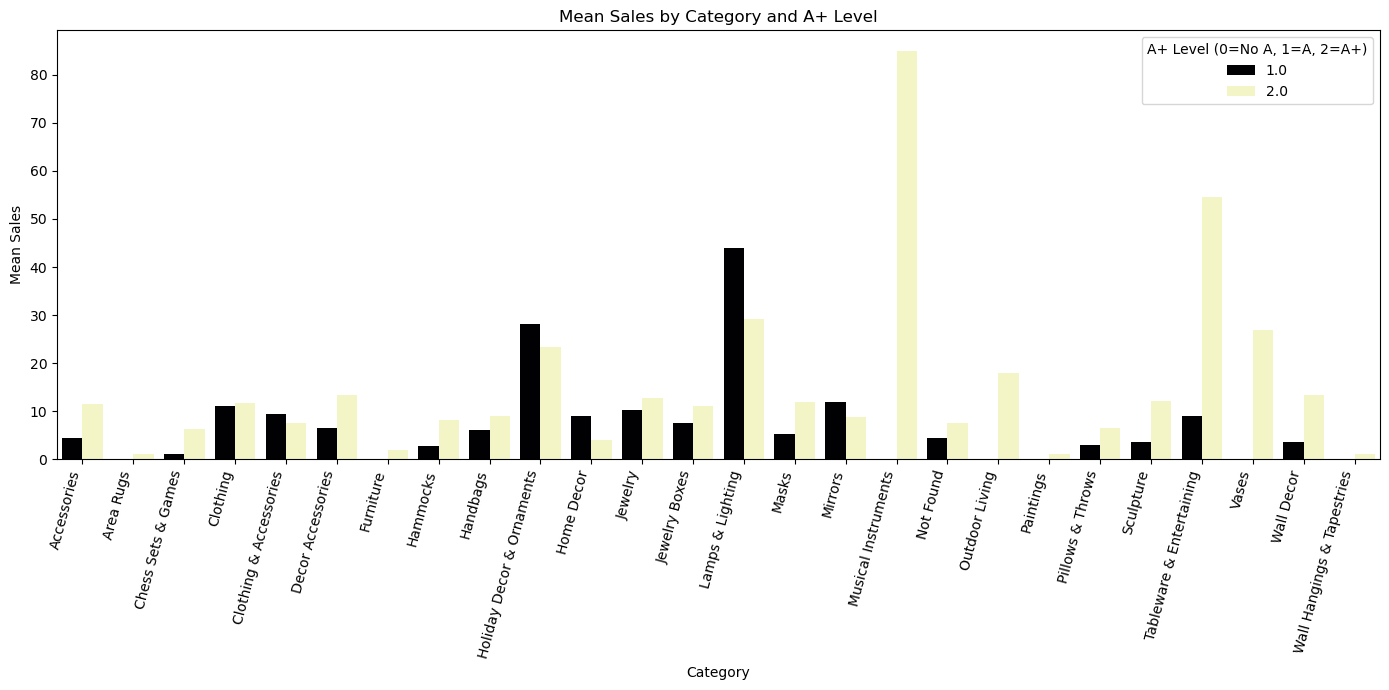

In [100]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=mean_table,
    x="category",
    y="sales",
    hue="aplus_num",
    palette="magma"
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Category")
plt.ylabel("Mean Sales")
plt.title("Mean Sales by Category and A+ Level")
plt.legend(title="A+ Level (0=No A, 1=A, 2=A+)")
plt.tight_layout()
plt.show()


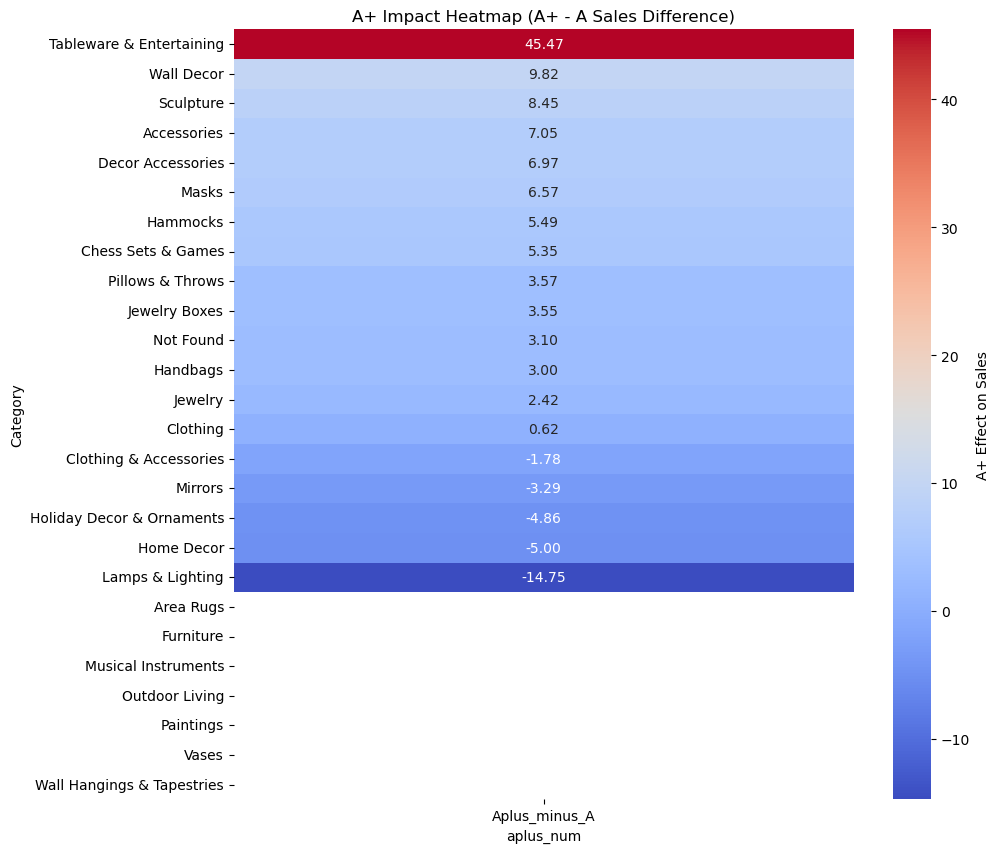

In [89]:
# Pivot to get A+ vs A table
pivot_aplus = mean_table.pivot(index="category", columns="aplus_num", values="sales")

# Compute difference: A+ - A
pivot_aplus["Aplus_minus_A"] = pivot_aplus.get(2, np.nan) - pivot_aplus.get(1, np.nan)

# Heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(
    pivot_aplus[["Aplus_minus_A"]].sort_values("Aplus_minus_A", ascending=False),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar_kws={"label": "A+ Effect on Sales"}
)

plt.title("A+ Impact Heatmap (A+ - A Sales Difference)")
plt.ylabel("Category")
plt.show()


In [93]:
# === Regression with Interaction Terms ===
interaction_formula = """
log_sales ~ aplus_num + rating_num + videos + images
            + C(category)
            + aplus_num:C(category)
            + rating_num:C(category)
            + videos:C(category)
            + images:C(category)
"""

model_interactions = smf.ols(interaction_formula, data=df_obj4).fit()
print("=== REGRESSION WITH CONTENT × CATEGORY INTERACTIONS ===")
print(model_interactions.summary())


=== REGRESSION WITH CONTENT × CATEGORY INTERACTIONS ===
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     8.999
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          2.29e-115
Time:                        19:10:33   Log-Likelihood:                -5670.5
No. Observations:                3529   AIC:                         1.155e+04
Df Residuals:                    3424   BIC:                         1.220e+04
Df Model:                         104                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

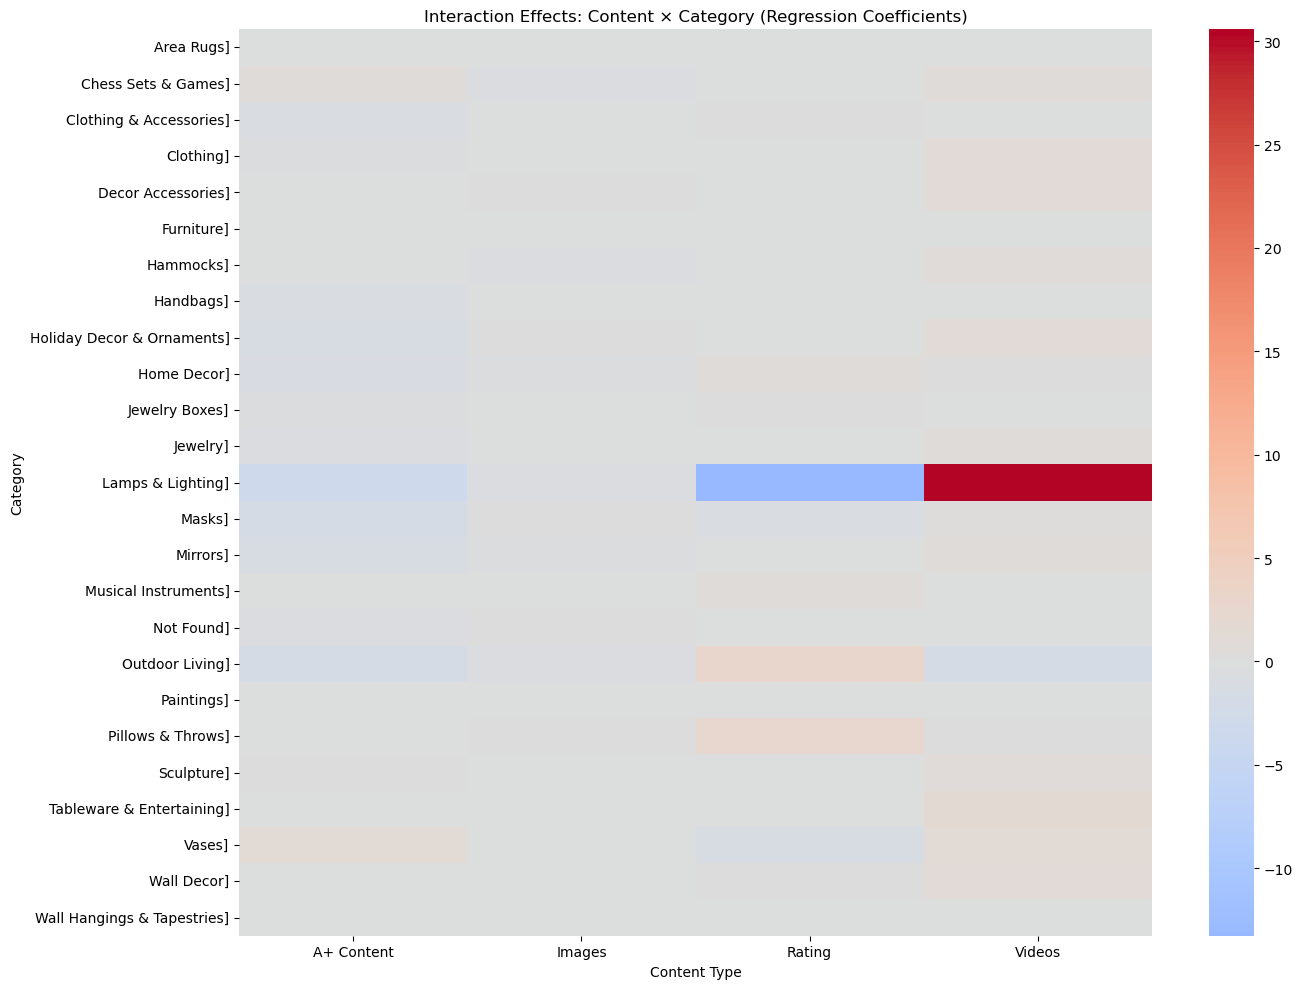

In [97]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Extract interaction coefficients only
interaction_data = []

for term, coef in model_interactions.params.items():
    if ":" in term:
        var, cat = term.split(":")
        category_name = cat.split("T.")[1]
        
        if "aplus" in term:
            variable = "A+ Content"
        elif "rating" in term:
            variable = "Rating"
        elif "videos" in term:
            variable = "Videos"
        elif "images" in term:
            variable = "Images"
        else:
            continue
        
        interaction_data.append([category_name, variable, coef])

# Convert to DataFrame
df_inter = pd.DataFrame(interaction_data, columns=["Category", "Variable", "Coefficient"])

# Pivot for heatmap
heatmap_df = df_inter.pivot(index="Category", columns="Variable", values="Coefficient")

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_df, annot=False, cmap="coolwarm", center=0)
plt.title("Interaction Effects: Content × Category (Regression Coefficients)")
plt.xlabel("Content Type")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [105]:
import pandas as pd
import statsmodels.formula.api as smf

# ---------------------------------------
# CATEGORY-SPECIFIC REGRESSIONS
# log_sales ~ aplus_num + rating_num + videos + images
# ---------------------------------------

results = []  # to store coefficient info per category

min_obs = 30  # minimum rows per category to fit a stable model

for cat, sub in df_obj4.groupby("category"):
    # skip very small categories
    if len(sub) < min_obs:
        print(f"Skipping {cat} (only {len(sub)} rows)")
        continue
    
    # define the category-specific model
    formula_cat = "log_sales ~ aplus_num + rating_num + videos + images"
    
    try:
        model_cat = smf.ols(formula=formula_cat, data=sub).fit()
        
        # store coefficients & p-values for content variables
        for var in ["aplus_num", "rating_num", "videos", "images"]:
            if var in model_cat.params.index:
                results.append({
                    "category": cat,
                    "variable": var,
                    "coef": model_cat.params[var],
                    "pval": model_cat.pvalues[var],
                    "R2": model_cat.rsquared,
                    "n_obs": len(sub)
                })
                
        # (optional) print a short summary per category
        print(f"\n=== Category: {cat} ===")
        print(model_cat.summary().tables[1])  # only coefficients table
        
    except Exception as e:
        print(f"Error in category {cat}: {e}")

# Turn results into a DataFrame
cat_reg_results = pd.DataFrame(results)
cat_reg_results.head()



=== Category: Accessories ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0157      1.325     -0.766      0.445      -3.647       1.616
aplus_num      0.4447      0.470      0.947      0.346      -0.488       1.377
rating_num     0.0762      0.119      0.638      0.525      -0.161       0.313
videos         0.4260      0.224      1.898      0.061      -0.020       0.872
images         0.1419      0.086      1.653      0.102      -0.029       0.312
Skipping Area Rugs (only 1 rows)
Skipping Chess Sets & Games (only 27 rows)

=== Category: Clothing ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2526      1.996     -0.627      0.532      -5.234       2.729
aplus_num      0.1760      0.871      0.202      0.840      -1.562       1.

,category,variable,coef,pval,R2,n_obs
0,Accessories,aplus_num,0.444694,0.346059,0.076901,100
1,Accessories,rating_num,0.076174,0.524696,0.076901,100
2,Accessories,videos,0.425984,0.060714,0.076901,100
3,Accessories,images,0.141864,0.101718,0.076901,100
4,Clothing,aplus_num,0.176011,0.840488,0.193020,75


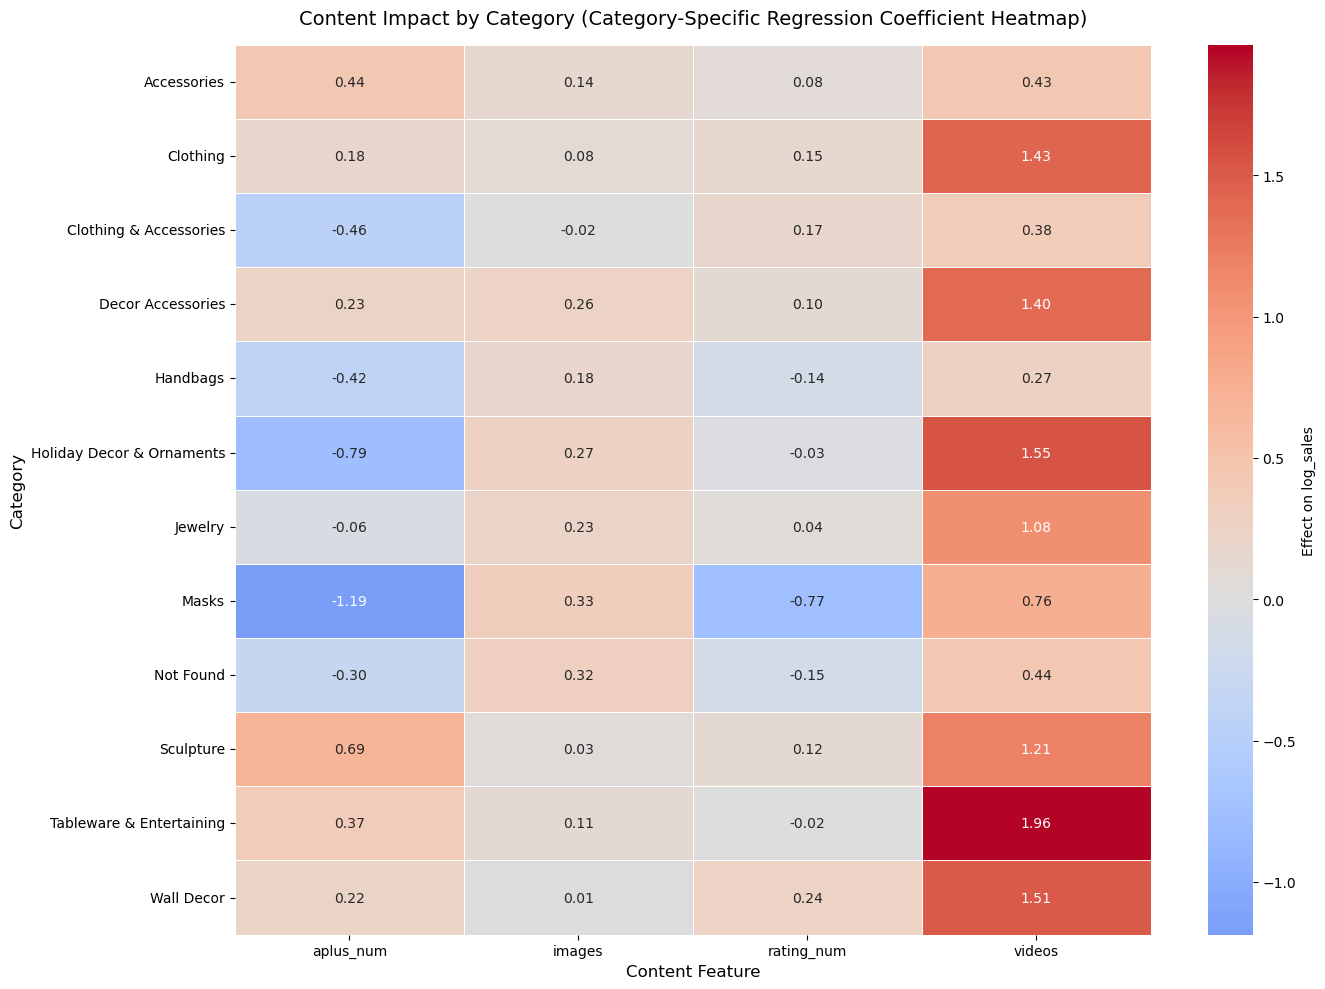

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot to create category × variable matrix
coef_matrix = cat_reg_results.pivot(index="category", columns="variable", values="coef")

plt.figure(figsize=(14, 10))
sns.heatmap(
    coef_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"label": "Effect on log_sales"}
)

plt.title("Content Impact by Category (Category-Specific Regression Coefficient Heatmap)", fontsize=14, pad=15)
plt.xlabel("Content Feature", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()


In [115]:
# Subset and drop NA
df_manova = df_obj4.dropna(subset=["sales", "rating_num", "images", "videos"])

manova_model = MANOVA.from_formula(
    "sales + rating_num + images + videos ~ C(category)",
    data=df_manova
)

print("=== MANOVA: sales + rating + images + videos ~ category ===")
print(manova_model.mv_test())


=== MANOVA: sales + rating + images + videos ~ category ===
                    Multivariate linear model
                                                                  
------------------------------------------------------------------
         Intercept        Value  Num DF   Den DF   F Value  Pr > F
------------------------------------------------------------------
            Wilks' lambda 0.3194 4.0000 3500.0000 1864.6631 0.0000
           Pillai's trace 0.6806 4.0000 3500.0000 1864.6631 0.0000
   Hotelling-Lawley trace 2.1310 4.0000 3500.0000 1864.6631 0.0000
      Roy's greatest root 2.1310 4.0000 3500.0000 1864.6631 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
      C(category)       Value   Num DF    Den DF   F Value  Pr > F
------------------------------------------------------------------
          Wilks' lambda

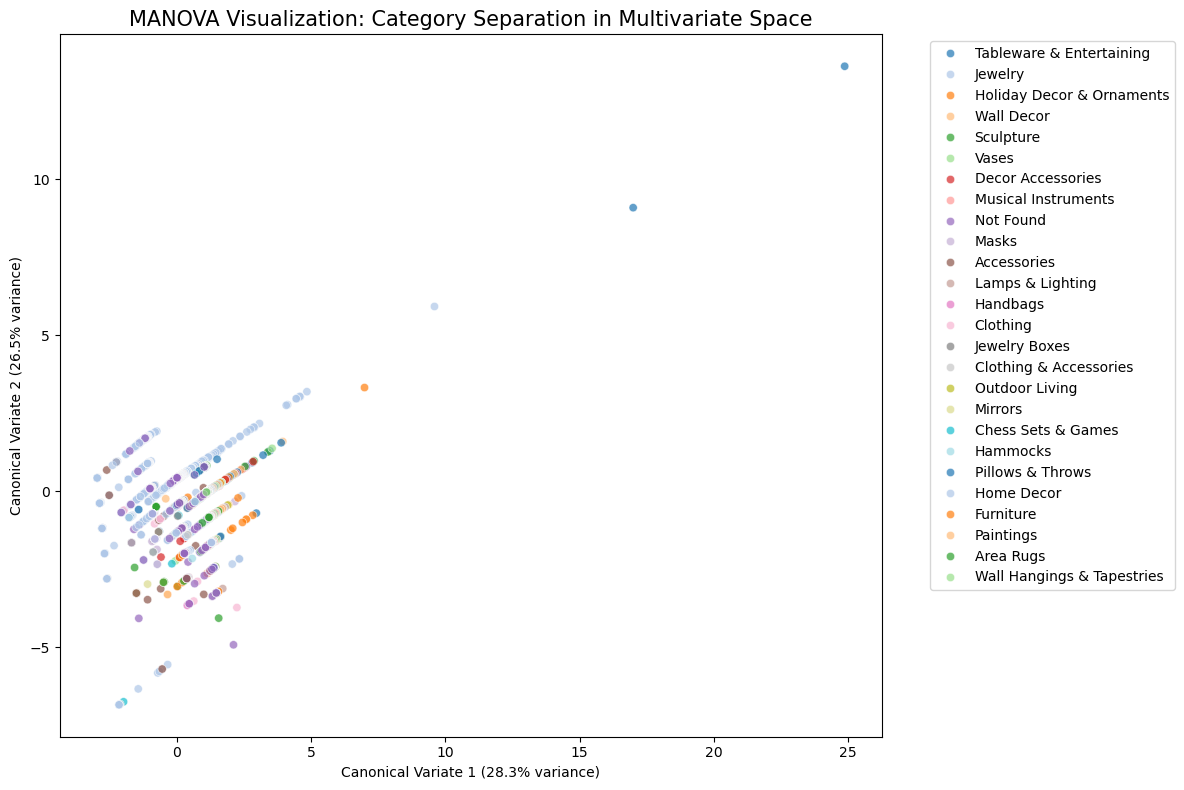

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# MANOVA variables
X = df_obj4[["sales", "rating_num", "images", "videos"]]
y = df_obj4["category"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to approximate canonical variates
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "CV1": pca_scores[:, 0],
    "CV2": pca_scores[:, 1],
    "Category": y
})

# Plot canonical space
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca,
    x="CV1",
    y="CV2",
    hue="Category",
    palette="tab20",
    alpha=0.7
)

plt.title("MANOVA Visualization: Category Separation in Multivariate Space", fontsize=15)
plt.xlabel(f"Canonical Variate 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Canonical Variate 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
